# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.eval import plot_temperature_triptych
from src.dataset import load_mnist_tensor

import matplotlib.pyplot as plt
import torch 
import numpy as np

# MNIST Dataset

In [2]:
dataset="mnist"

sigma=1.0
n_bins=220
n_samples=4
k=4.0
n_replicas=3

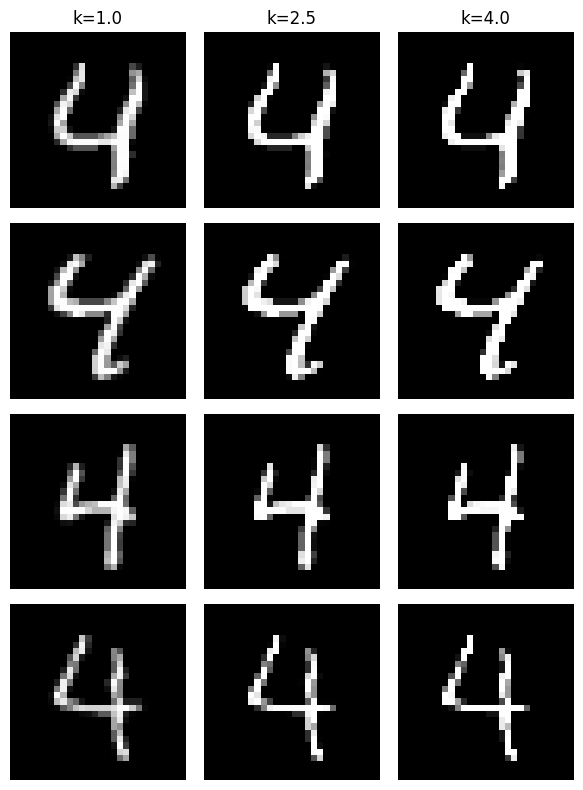

In [3]:
def apply_temperature(x, k=1.0):
    """x in [0,1]. k>1 sharpens, k<1 flattens."""
    x = x.clamp(1e-6, 1 - 1e-6)  # avoid log(0)
    logits = torch.log(x / (1 - x))  # inverse sigmoid
    logits = logits * k              # scale by temperature
    return torch.sigmoid(logits)     # back to [0,1]

x = load_mnist_tensor(train=False, normalize_to_minus1_1=False)

ks = np.linspace(1.0, k, n_replicas)
fig, axes = plt.subplots(n_samples, len(ks), figsize=(len(ks) * 2, n_samples*2))

for row in range(n_samples):
    for col, k in enumerate(ks):
        img = apply_temperature(x[row, 0], k=k)
        axes[row, col].imshow(img.numpy(), cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"k={k}")

plt.tight_layout()
plt.show()

0.1327439844608307
std 0.3112172782421112
0.16836194694042206
std 0.34686943888664246
0.13823962211608887
std 0.3249063789844513


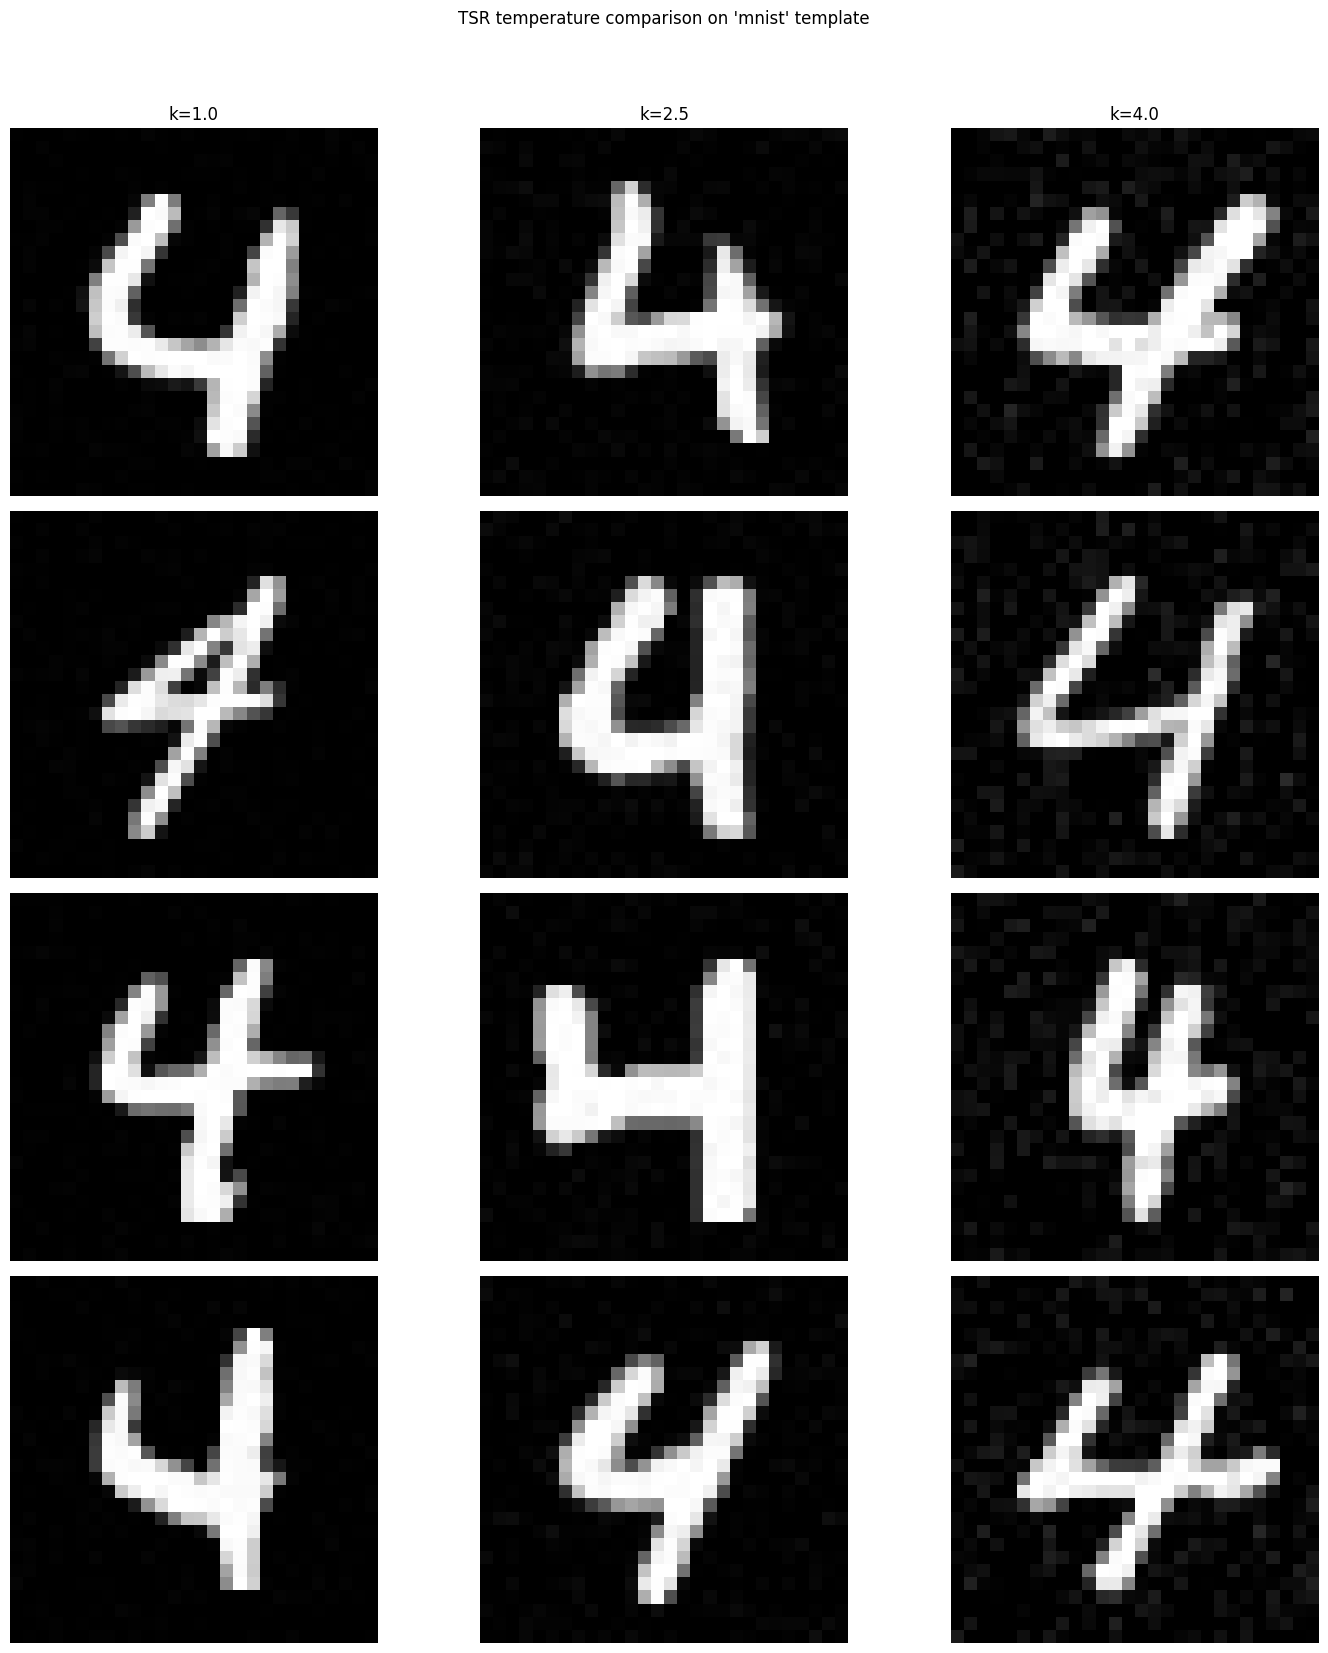

In [4]:
_ = plot_temperature_triptych(dataset_name=dataset, sigma=sigma, n_bins=n_bins, n_samples=n_samples, k=k, replica_swaps=False)

Time 90 swap 0.9990801215171814
Time 80 swap 0.9839022159576416
Time 70 swap 0.9891294836997986
Time 60 swap 0.9243746399879456
Time 50 swap 0.9600387811660767
0.12230893224477768
std 0.297382116317749
0.1504909247159958
std 0.32960742712020874
0.1378561109304428
std 0.32696229219436646


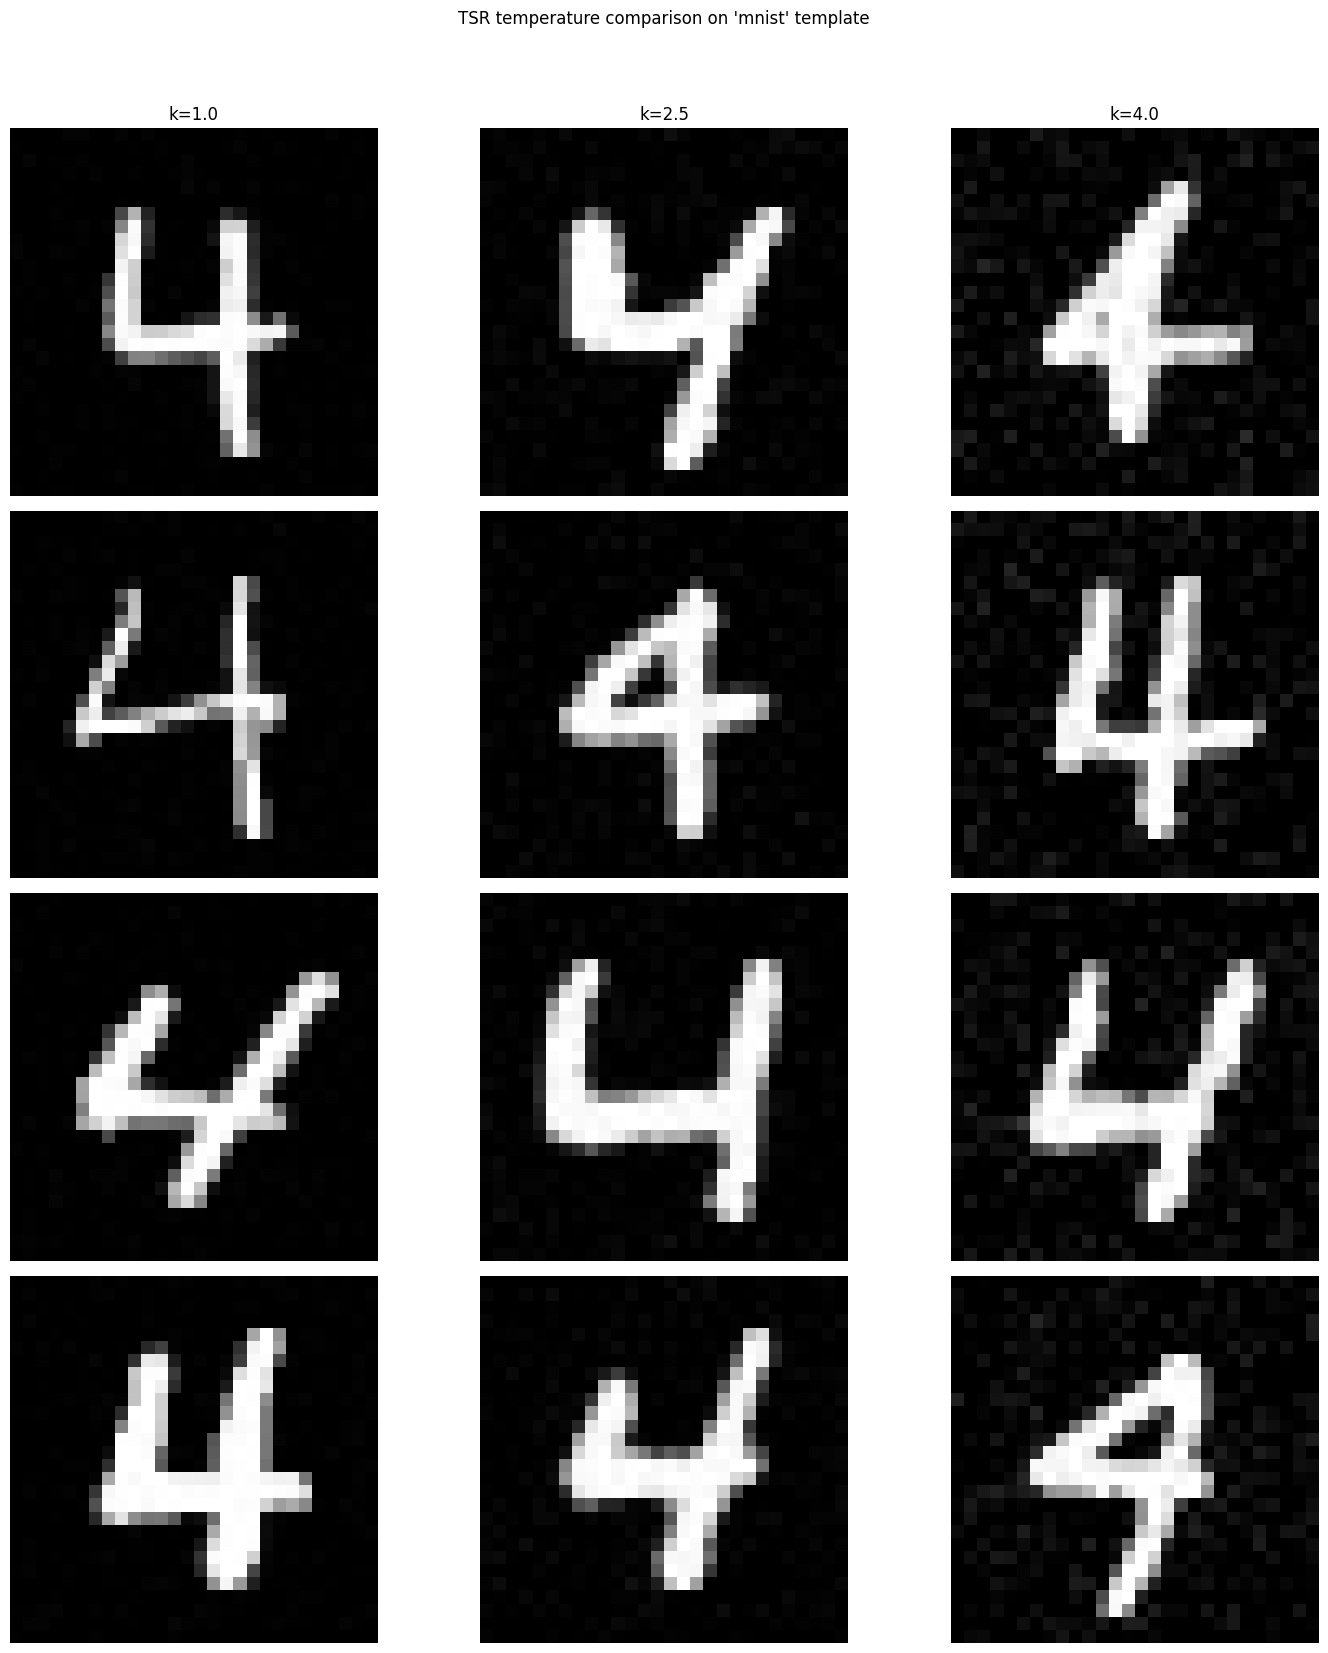

In [5]:
_ = plot_temperature_triptych(dataset_name=dataset, sigma=sigma, n_bins=n_bins, n_samples=n_samples, k=k, replica_swaps=True)

# Composed Dataset

In [6]:
dataset="composed"

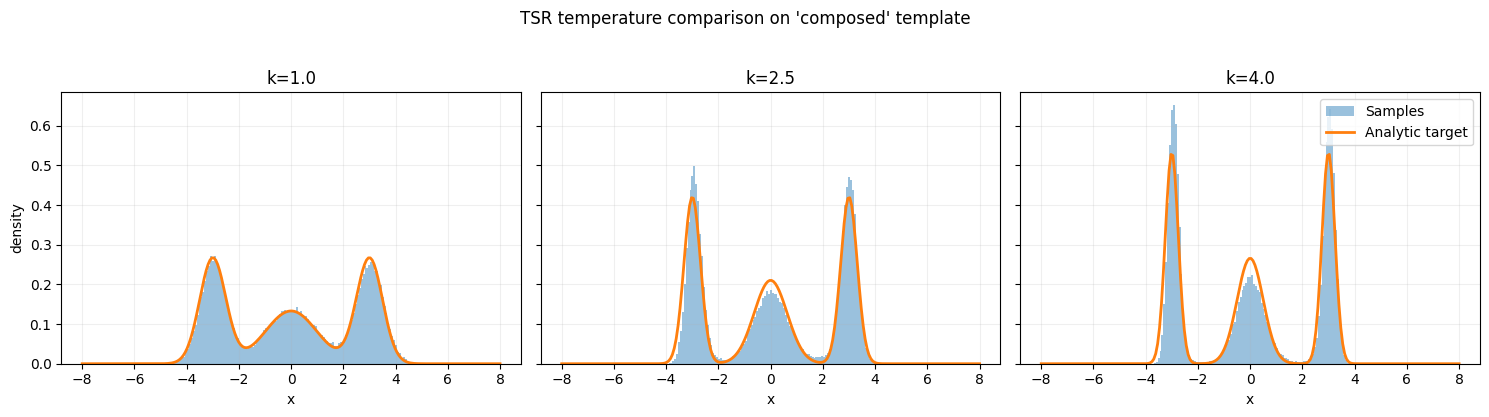

In [7]:
_ = plot_temperature_triptych(dataset_name=dataset, sigma=sigma, n_bins=n_bins, n_samples=n_samples, k=k, replica_swaps=False)

Time 90 swap 0.9990430474281311
Time 80 swap 0.9846011996269226
Time 70 swap 0.9921361207962036
Time 60 swap 0.9587445259094238
Time 50 swap 0.981547474861145


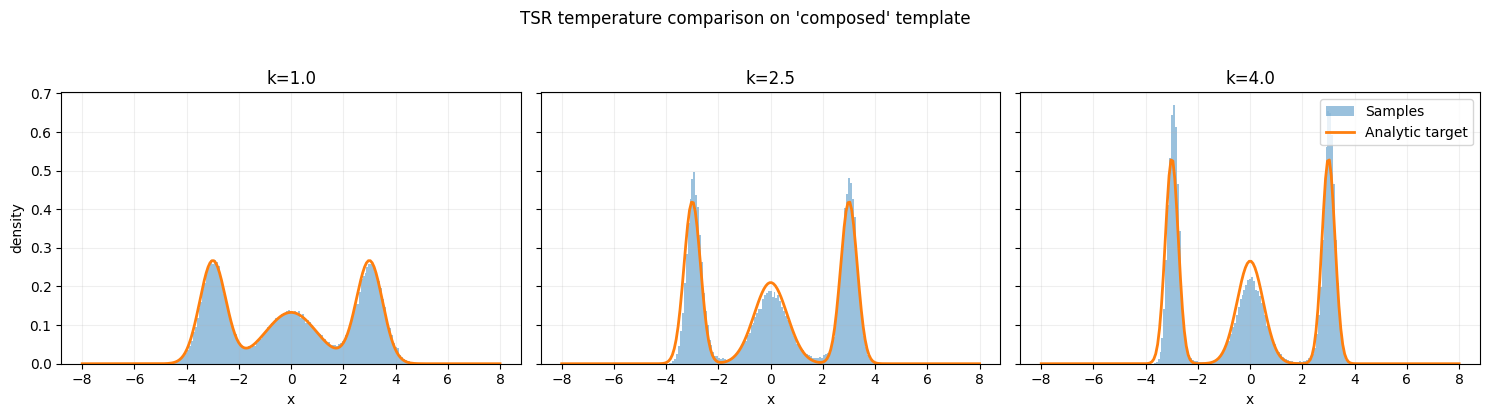

In [8]:
_ = plot_temperature_triptych(dataset_name=dataset, sigma=sigma, n_bins=n_bins, n_samples=n_samples, k=k, replica_swaps=True)